# $\textbf{Final Project — Maternal Health Risk Hybrid Expert System}$

### $\textit{Pipeline:}\;\; \text{Patient} \;\to\; NN_1 \;\to\; NN_2 \;\to\; \text{Certainty-Factor Expert System} \;\to\; \text{Diagnosis}$

This project predicts the **risk level during pregnancy** (*low* / *mid* / *high*) using a **chained hybrid system** that mixes data-driven evidence (two stacked neural networks) with knowledge-driven evidence (clinical certainty-factor rules from the course material).

$$
\text{Patient} \;\longrightarrow\; \boxed{NN_1} \;\longrightarrow\; \boxed{NN_2} \;\longrightarrow\; \boxed{\text{Expert System (CF)}} \;\longrightarrow\; \text{Final Diagnosis}
$$

&emsp;&emsp;**$NN_1$** &mdash; *Stage-1 classifier.* Reads the 6 scaled vitals and outputs a probability vector $\bigl[\,P_\text{low},\,P_\text{mid},\,P_\text{high}\,\bigr]$.<br>
&emsp;&emsp;**$NN_2$** &mdash; *Stage-2 refiner.* Takes $NN_1$'s probability vector **concatenated** with the original scaled vitals and outputs a refined probability vector for the final class.<br>
&emsp;&emsp;**Expert System** &mdash; uses $NN_2$'s $P(\text{high risk})$ as the **seed certainty factor**, fires clinical rules, and combines all CFs with the formula
$$
total\_cf = total\_cf + cf \cdot (1 - total\_cf)
$$

The neural networks and the rule base **complete each other**: the chain finds patterns hidden in the data, the rules add explicit clinical knowledge, and the certainty-factor formula merges both into a single number with a clinical meaning.

---

### $\textit{Dataset}$ &mdash; UCI Maternal Health Risk *(Donated 2023)*

| Feature       | Unit    | Meaning                          |
|---------------|---------|----------------------------------|
| Age           | years   | Mother's age                     |
| SystolicBP    | mmHg    | Upper blood pressure             |
| DiastolicBP   | mmHg    | Lower blood pressure             |
| BS            | mmol/L  | Blood sugar                      |
| BodyTemp      | °F      | Body temperature                 |
| HeartRate     | bpm     | Heart rate                       |
| RiskLevel     | &mdash; | **Target**: low / mid / high risk |

Source &mdash; <https://archive.ics.uci.edu/dataset/863/maternal+health+risk>

### $\textit{Reference papers}$ *(PDFs in `papers/`)*
1. **Togunwa et al. (2023)** &mdash; *Frontiers in AI* &mdash; ANN + Random Forest hybrid (94.88%).
2. **Saleem et al. (2024)** &mdash; *Scientific Reports* &mdash; Quad-Ensemble framework.
3. **Jamel et al. (2024)** &mdash; *PeerJ CS* &mdash; MLP + ExtraTree + PCA (98.25%).


## $1.$ ***Importing Libraries & Data***

*Bring in `numpy` / `pandas` for tabular work, `matplotlib` + `seaborn` for plots, `joblib` for model persistence, and silence the noisy sklearn convergence warnings.*

In [77]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import joblib
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
%matplotlib inline

In [78]:
data = pd.read_csv('data/Maternal Health Risk Data Set.csv')

## $2.$ ***Exploring Data***

*Looking at what we have before we touch anything &mdash; shape, dtypes, summary statistics, class balance, then per-feature histograms, the correlation matrix, and box-plots split by risk level.*

In [79]:
data.head()

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
0,25,130,80,15.0,98.0,86,high risk
1,35,140,90,13.0,98.0,70,high risk
2,29,90,70,8.0,100.0,80,high risk
3,30,140,85,7.0,98.0,70,high risk
4,35,120,60,6.1,98.0,76,low risk


In [80]:
data.shape

(1014, 7)

In [81]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1014 entries, 0 to 1013
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          1014 non-null   int64  
 1   SystolicBP   1014 non-null   int64  
 2   DiastolicBP  1014 non-null   int64  
 3   BS           1014 non-null   float64
 4   BodyTemp     1014 non-null   float64
 5   HeartRate    1014 non-null   int64  
 6   RiskLevel    1014 non-null   object 
dtypes: float64(2), int64(4), object(1)
memory usage: 55.6+ KB


In [82]:
data.describe()

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate
count,1014.000000,1014.000000,1014.000000,1014.000000,1014.000000,1014.000000
mean,29.871795,113.198225,76.460552,8.725986,98.665089,74.301775
std,13.474386,18.403913,13.885796,3.293532,1.371384,8.088702
min,10.000000,70.000000,49.000000,6.000000,98.000000,7.000000
25%,19.000000,100.000000,65.000000,6.900000,98.000000,70.000000
50%,26.000000,120.000000,80.000000,7.500000,98.000000,76.000000
75%,39.000000,120.000000,90.000000,8.000000,98.000000,80.000000
max,70.000000,160.000000,100.000000,19.000000,103.000000,90.000000


In [132]:
data[data['Age' ] < 15][data['RiskLevel'] == 'high risk'].reset_index()

,index,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
0,145,14.0,90.0,65.0,7.00,98.0,70.0,high risk
1,171,12.0,90.0,60.0,7.90,98.0,66.0,high risk
2,267,12.0,90.0,60.0,8.00,98.0,66.0,high risk
3,276,12.0,90.0,60.0,9.65,98.0,60.0,high risk
4,285,13.0,90.0,65.0,9.00,98.0,80.0,high risk
5,371,12.0,90.0,60.0,7.80,98.0,60.0,high risk
6,610,13.0,90.0,65.0,7.50,98.0,80.0,high risk
7,685,14.0,90.0,65.0,7.00,98.0,70.0,high risk
8,957,14.0,90.0,65.0,7.00,98.0,70.0,high risk
9,963,12.0,90.0,60.0,7.90,98.0,66.0,high risk


In [83]:
data['RiskLevel'].value_counts()

RiskLevel
low risk     406
mid risk     336
high risk    272
Name: count, dtype: int64

In [84]:
numerical_columns   = list(set(data.select_dtypes(include='number').columns))
categorical_columns = list(set(data.columns) - set(numerical_columns))

print('numerical   :', numerical_columns)
print('categorical :', categorical_columns)

numerical   : ['DiastolicBP', 'BS', 'Age', 'HeartRate', 'SystolicBP', 'BodyTemp']
categorical : ['RiskLevel']


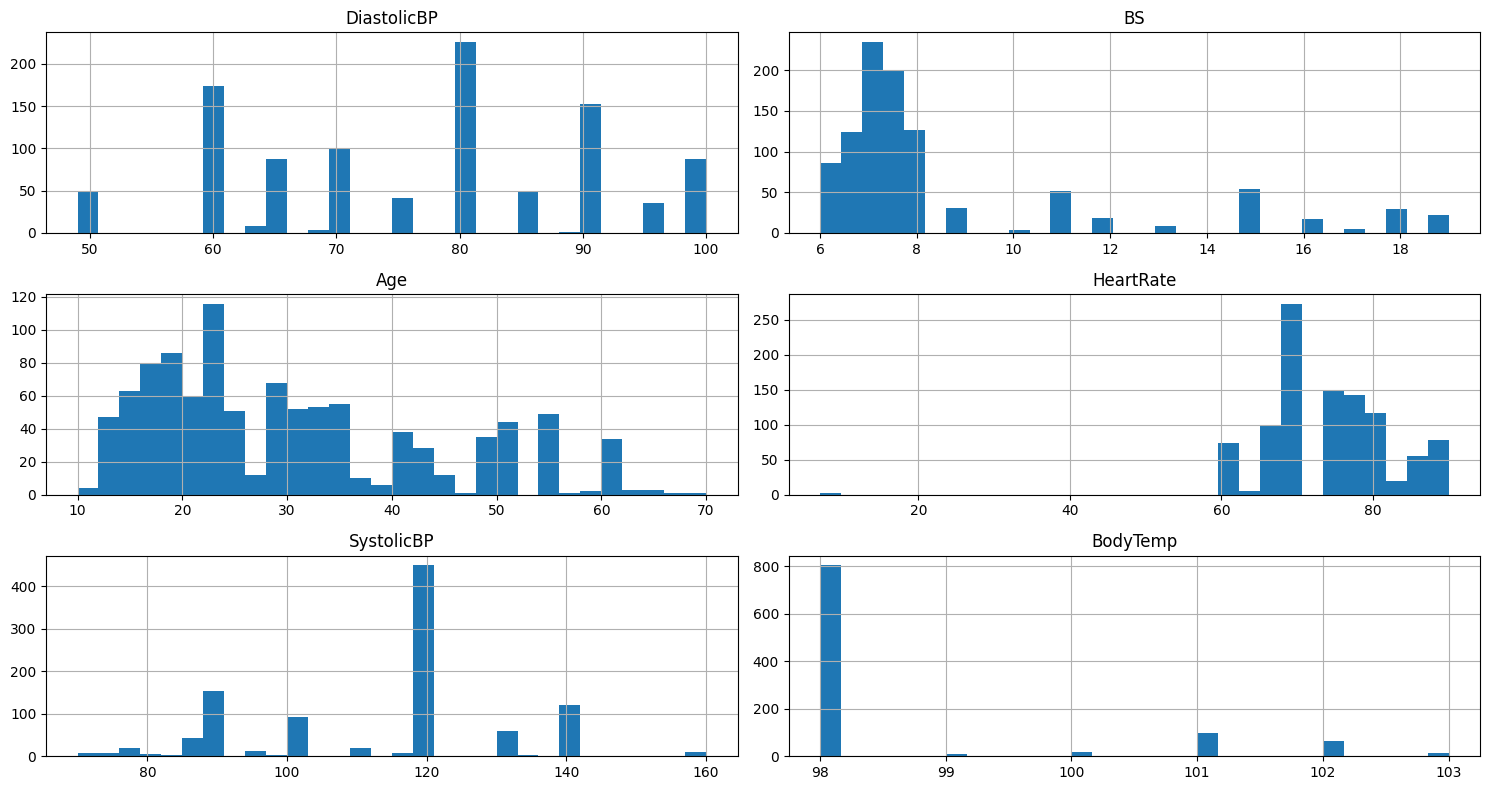

In [85]:
data[numerical_columns].hist(bins=30, figsize=(15, 8))
plt.tight_layout()
plt.show()

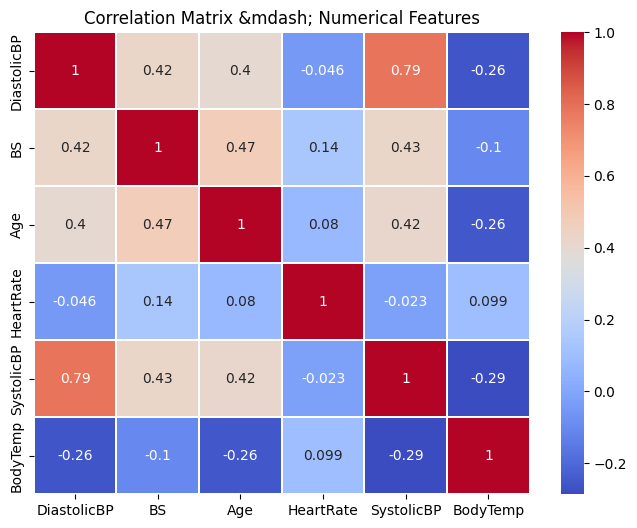

In [86]:
corr_matrix = data[numerical_columns].corr()
plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', linewidths=0.1)
plt.title('Correlation Matrix &mdash; Numerical Features')
plt.show()

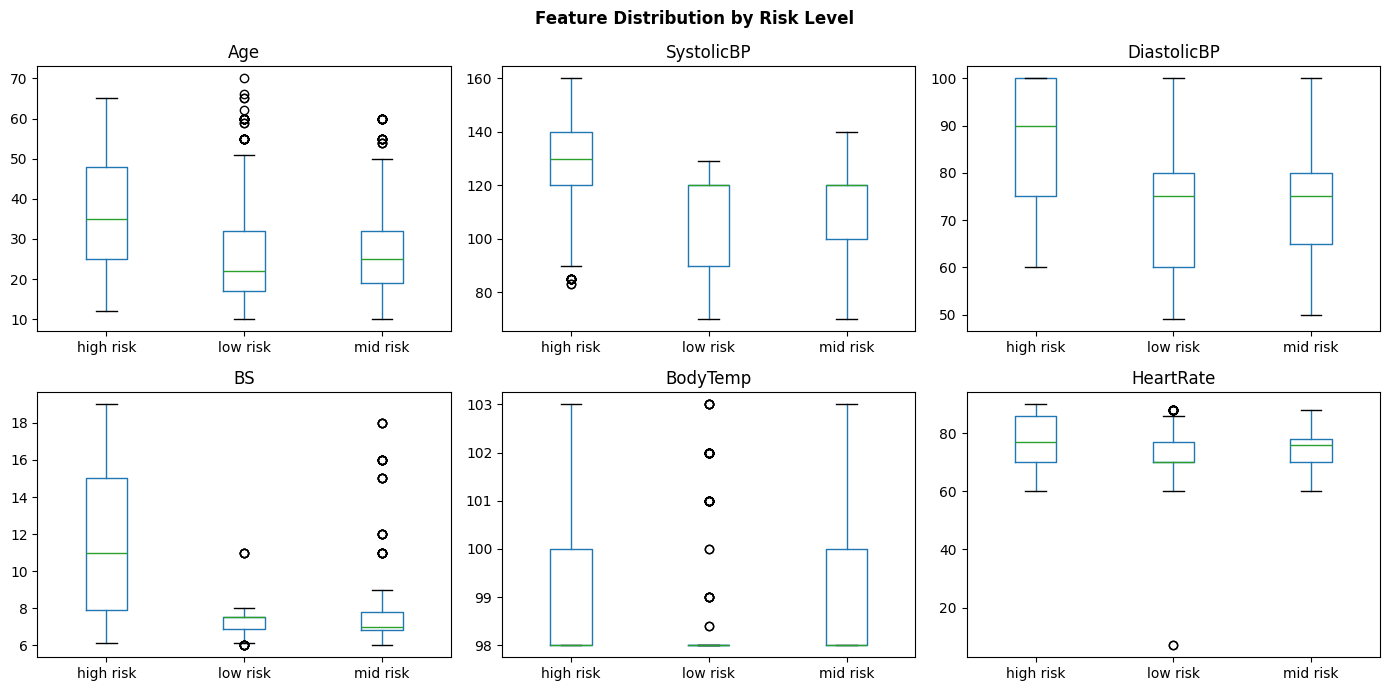

In [87]:
features = ['Age','SystolicBP','DiastolicBP','BS','BodyTemp','HeartRate']
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, feat in zip(axes.flat, features):
    data.boxplot(column=feat, by='RiskLevel', ax=ax, grid=False)
    ax.set_title(feat); ax.set_xlabel('')
plt.suptitle('Feature Distribution by Risk Level', fontweight='bold')
plt.tight_layout()
plt.show()

## $3.$ ***Handling Null Values***

*Calculate the count of nulls for each column and inspect any column with $>0$ nulls. **This dataset is clean** &mdash; no nulls to impute or drop &mdash; but the recipe is here for completeness.*

In [88]:
nulls_df = data.isna().sum().reset_index().rename(columns={0:'Nulls_Count'})
nulls_df[nulls_df['Nulls_Count']>0].sort_values(by=['Nulls_Count'], ascending=False)

,index,Nulls_Count


## $4.$ ***Outliers***
**Using The $IQR$ (Inter-Quartile Range) method:**

&emsp;&emsp;***$IQR$***: *gives a sense of the data's spread around the median, excluding possible outliers.*<br>
&emsp;&emsp;&emsp;&emsp;&emsp;--> ***$IQR = Q_3 - Q_1$***<br>
&emsp;&emsp;&emsp;&emsp;&emsp;--> ***$Q_1$*** = the median of the set of numbers below the median.<br>
&emsp;&emsp;&emsp;&emsp;&emsp;--> ***$Q_3$*** = the median of the set of numbers above the median.<br>

*The Upper bound* $= Q_3 + 1.5 \cdot IQR$<br>
*The Lower bound* $= Q_1 - 1.5 \cdot IQR$

> Values that fall outside these bounds are *clamped* to the bound (instead of being deleted) so we keep the row but cap its extreme value.

In [89]:
def Clamping_Outliers(df, Target_Columns, threshold=1.5):
    for col in Target_Columns:
        df[col] = df[col].astype(float)

        Q1 = np.percentile(df[col], 25)
        Q3 = np.percentile(df[col], 75)

        IQR = Q3 - Q1

        Upper = Q3 + threshold * IQR
        Lower = Q1 - threshold * IQR

        df.loc[df[col] < Lower, col] = Lower
        df.loc[df[col] > Upper, col] = Upper
    return df

In [90]:
data = Clamping_Outliers(data, features)

## $5.$ ***Skewness***
***The danger of Skewness:***  the fanning-out of the regression line resulting in high variance ($\sigma^2$) across data points.<br>

### *Types of Skewness*:
***1- Left-Skewed (Negative-Skewed):*** *"Median" and "Mean" are shifted to the **left** of "Mode".*<br>
***2- Right-Skewed (Positive-Skewed):*** *"Median" and "Mean" are shifted to the **right** of "Mode".*<br>

***$Z$-$Score$:*** how many standard deviations ($\sigma$) from the mean a data point is.
$$
Z = \frac{x - \mu}{\sigma}
$$

The **skewness coefficient** is the average value of $Z^3$:
$$
\text{Skewness} = \frac{\sum_{i=1}^{N} (X_i - \bar{X})^{3}}{(N-1)\,\sigma^{3}}
$$

***--> After detecting skewed-data we transform & normalise. Here we use a sign-aware $Log$-$Transformation$:***
$$
Y = \operatorname{sign}(x)\,\cdot\,\log\!\bigl(1 + |x|\bigr)
$$

In [91]:
def Skewness_calculator(df: pd.DataFrame, Target_columns: list):
    means = df[Target_columns].mean(axis=0)
    stds  = df[Target_columns].std(axis=0)
    skewness_dictionary = (((df[Target_columns] - means)**3).sum(axis=0)) / ((df.shape[0] - 1) * stds**3)
    return skewness_dictionary

In [92]:
def Skewness_transformation(df: pd.DataFrame, Target_columns: list, threshold: float = 1.0):
    skewness_val = Skewness_calculator(df, Target_columns)
    transformed  = []
    for col, sk in skewness_val.items():
        if abs(sk) > threshold:
            df[col] = np.sign(df[col]) * np.log1p(df[col].abs())
            transformed.append(col)
            print(f"column {col} is transformed (skewness={sk:+.3f})")
    return df, transformed

In [93]:
data, skewed_columns = Skewness_transformation(data, features, threshold=1.0)
print('\nlog-transformed columns:', skewed_columns)


log-transformed columns: []


In [94]:
Skewness_calculator(data, features)

Age            0.780342
SystolicBP    -0.330441
DiastolicBP   -0.048345
BS             0.684170
BodyTemp            NaN
HeartRate      0.046803
dtype: float64

## $6.$ ***Encoding the Target***

*The MLP outputs integers* &mdash; *we use a `LabelEncoder` to map* `'low risk' / 'mid risk' / 'high risk'` *to* `0 / 1 / 2`.

In [95]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y  = le.fit_transform(data['RiskLevel'])
print('classes  :', list(le.classes_))
print('encoded  :', list(range(len(le.classes_))))

classes  : ['high risk', 'low risk', 'mid risk']
encoded  : [0, 1, 2]


In [96]:
X = data.drop('RiskLevel', axis=1)
X.head()

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate
0,25.0,130.0,80.0,9.65,98.0,86.0
1,35.0,140.0,90.0,9.65,98.0,70.0
2,29.0,90.0,70.0,8.00,98.0,80.0
3,30.0,140.0,85.0,7.00,98.0,70.0
4,35.0,120.0,60.0,6.10,98.0,76.0


## $7.$ ***Feature Scaling***
### **The importance of feature scaling:**<br>
&emsp;&emsp;&emsp; $1.$ Fixes value-range or unit issues that cause bias in distance-based and gradient-based algorithms (gradient descent, $KNN$, $SVM$, neural networks).<br>
&emsp;&emsp;&emsp; $2.$ Prevents collinearity when interaction terms are created from features that are not centred on $0$.<br><br>

### **Methods of feature scaling:**<br>
&emsp;&emsp;&emsp;$1.$ ***Normalization*** ($Min$-$Max$): values squeezed into $[0, 1]$.<br>
&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp; ***$Formula$***: $\;\; x' = \dfrac{x - x_{\min}}{x_{\max} - x_{\min}}$<br>
&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp; **-->** *Highly affected by outliers.*<br><br>
&emsp;&emsp;&emsp;$2.$ ***Standardization*** ($Z$-$score$): re-centred to mean $0$ and unit variance.<br>
&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp; ***$Formula$***: $\;\; z = \dfrac{x - \mu}{\sigma}$<br>
&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp; **-->** *Less affected by outliers; assumes near-normal data.*<br><br>
&emsp;&emsp;&emsp;$3.$ ***Robust Scaling***: uses median and $IQR$ instead of mean and $\sigma$.<br>
&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp; ***$Formula$***: $\;\; x' = \dfrac{x - \text{Median}(x)}{IQR}$<br>
&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp; **-->** *Very resistant to outliers.*<br>

> Our 6 vitals look approximately normal after the IQR clamp + log-skew transformation, so we go with **Standardization**.

In [97]:
def Standardization_Z_Score(df: pd.DataFrame, Target_Columns: list):
    for col in Target_Columns:
        df[col] = ((df[col] - df[col].mean()) / df[col].std())
    return df

In [98]:
from sklearn.preprocessing import StandardScaler

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)
X_scaled_df.head()

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate
0,-0.361743,0.930174,0.255023,1.700156,0.0,1.534850
1,0.380932,1.480559,0.975539,1.700156,0.0,-0.581537
2,-0.064673,-1.271369,-0.465493,0.250676,0.0,0.741205
3,0.009595,1.480559,0.615281,-0.627796,0.0,-0.581537
4,0.380932,0.379788,-1.186009,-1.418421,0.0,0.212108


*Choose what makes you feel comfortable* &mdash; for the rest of the notebook we use the **fitted `StandardScaler`**, because we need to persist its `mean_` and `scale_` to disk so the interface can re-apply the exact same transformation at inference time.

## $8.$ ***Train-Test Split (Stratified)***

> The class proportions are *low : mid : high $\approx$ 40 : 33 : 27*.<br>
> A vanilla random split could under-represent the minority class in the test set; passing `stratify=y` to `train_test_split` keeps the same proportions in both halves.

In [99]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size    = 0.20,
    random_state = 42,
    stratify     = y,
)

print(f"train set : {X_train.shape[0]} patients")
print(f"test  set : {X_test.shape[0]} patients")

train set : 811 patients
test  set : 203 patients


## $9.$ ***Hybrid Architecture: $NN_1 \to NN_2 \to$ Expert System***

We don't train one big neural network. We **chain two smaller ones** &mdash; a stacking-style refinement &mdash; and feed the second one's output into the rule-based expert system.

```
   patient (6 vitals)
         │
         ▼   StandardScaler
         ▼
   ┌─────────────┐
   │    NN_1     │   hidden_layer_sizes tuned in §9.1
   │  (stage 1)  │   output: [P_low, P_mid, P_high]
   └─────┬───────┘
         │  concat(scaled features, NN_1 probs)   ← chain joint
         ▼
   ┌─────────────┐
   │    NN_2     │   hidden_layer_sizes tuned in §9.2
   │  (stage 2)  │   output: refined [P_low, P_mid, P_high]
   └─────┬───────┘
         │  P(high risk)  →  seed certainty factor
         ▼
   ┌──────────────────────────────┐
   │ Expert System (CF rules)     │   §10
   │ combine_cf accumulates       │
   │ NN_chain CF + clinical CFs   │
   └─────┬────────────────────────┘
         │
         ▼
   final diagnosis  ∈  { LOW, MID, HIGH }
```

### *Why $NN_2$?*<br>
&emsp;&emsp;&emsp; $NN_2$ sees both the raw signal **and** $NN_1$'s opinion, so it can correct $NN_1$'s mistakes (it's the same idea as Géron's stacking ensemble in *Hands-on ML* Ch. 7, applied at the neural-network level instead of across model families).

## $9.1.$ ***$NN_1$ &mdash; Stage-1 Classifier***

*Try a few small architectures, pick the one with the best test accuracy.*

In [100]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

architectures = [(8,), (16,), (16, 8), (32, 16), (64,32), (128,64)]

In [101]:
print(f"{'architecture':<14} | {'test acc':<10} | iterations")
print('-' * 44)

results_nn1 = {}
for arch in architectures:
    nn = MLPClassifier(hidden_layer_sizes=arch, max_iter=1000, random_state=42)
    nn.fit(X_train, y_train)
    acc = accuracy_score(y_test, nn.predict(X_test))
    results_nn1[arch] = (acc, nn.n_iter_)
    print(f"{str(arch):<14} | {acc:<10.4f} | {nn.n_iter_}")

best_arch_nn1 = max(results_nn1, key=lambda a: results_nn1[a][0])
print(f"\nbest NN_1 architecture: {best_arch_nn1}  (acc={results_nn1[best_arch_nn1][0]:.4f})")

architecture   | test acc   | iterations
--------------------------------------------
(8,)           | 0.6355     | 445
(16,)          | 0.6650     | 509
(16, 8)        | 0.6749     | 561
(32, 16)       | 0.7291     | 658
(64, 32)       | 0.7833     | 463
(128, 64)      | 0.7241     | 311

best NN_1 architecture: (64, 32)  (acc=0.7833)


In [102]:
nn1 = MLPClassifier(
    hidden_layer_sizes = best_arch_nn1,
    activation         = 'relu',
    solver             = 'adam',
    learning_rate_init = 0.001,
    max_iter           = 1000,
    random_state       = 42,
)
nn1.fit(X_train, y_train)
print(f"NN_1 final loss : {nn1.loss_:.4f}   iterations : {nn1.n_iter_}")

NN_1 final loss : 0.4353   iterations : 463


In [103]:
y_pred_nn1 = nn1.predict(X_test)
print(f"NN_1 test accuracy : {accuracy_score(y_test, y_pred_nn1):.4f}\n")
print(classification_report(y_test, y_pred_nn1, target_names=le.classes_))

NN_1 test accuracy : 0.7833

              precision    recall  f1-score   support

   high risk       0.96      0.89      0.92        55
    low risk       0.73      0.80      0.76        81
    mid risk       0.71      0.67      0.69        67

    accuracy                           0.78       203
   macro avg       0.80      0.79      0.79       203
weighted avg       0.79      0.78      0.78       203



## $9.2.$ ***$NN_2$ &mdash; Stage-2 Refiner***

$NN_2$'s input is the **concatenation** of:

&emsp;&emsp;&emsp;**(a)** the original 6 scaled vitals &mdash; so $NN_2$ can still see the raw signal,<br>
&emsp;&emsp;&emsp;**(b)** the 3 class probabilities from $NN_1$ &mdash; so $NN_2$ can correct $NN_1$'s opinion.

> Input dimensionality: $6 + 3 = 9$.

In [104]:
nn1_probs_train = nn1.predict_proba(X_train)
nn1_probs_test  = nn1.predict_proba(X_test)

X_train_stage2 = np.hstack([X_train, nn1_probs_train])
X_test_stage2  = np.hstack([X_test,  nn1_probs_test])

print(f"NN_1 prob shape : {nn1_probs_train.shape}")
print(f"NN_2 input shape: {X_train_stage2.shape}")

NN_1 prob shape : (811, 3)
NN_2 input shape: (811, 9)


In [105]:
print(f"{'architecture':<14} | {'test acc':<10} | iterations")
print('-' * 44)

results_nn2 = {}
for arch in architectures:
    nn = MLPClassifier(hidden_layer_sizes=arch, max_iter=1000, random_state=42)
    nn.fit(X_train_stage2, y_train)
    acc = accuracy_score(y_test, nn.predict(X_test_stage2))
    results_nn2[arch] = (acc, nn.n_iter_)
    print(f"{str(arch):<14} | {acc:<10.4f} | {nn.n_iter_}")

best_arch_nn2 = max(results_nn2, key=lambda a: results_nn2[a][0])
print(f"\nbest NN_2 architecture: {best_arch_nn2}  (acc={results_nn2[best_arch_nn2][0]:.4f})")

architecture   | test acc   | iterations
--------------------------------------------
(8,)           | 0.7488     | 457
(16,)          | 0.7340     | 347
(16, 8)        | 0.7635     | 293
(32, 16)       | 0.7537     | 246
(64, 32)       | 0.7685     | 278
(128, 64)      | 0.7635     | 115

best NN_2 architecture: (64, 32)  (acc=0.7685)


In [106]:
nn2 = MLPClassifier(
    hidden_layer_sizes = best_arch_nn2,
    activation         = 'relu',
    solver             = 'adam',
    learning_rate_init = 0.001,
    max_iter           = 1000,
    random_state       = 42,
)
nn2.fit(X_train_stage2, y_train)
print(f"NN_2 final loss : {nn2.loss_:.4f}   iterations : {nn2.n_iter_}")

NN_2 final loss : 0.3547   iterations : 278


In [107]:
y_pred_nn2 = nn2.predict(X_test_stage2)
print(f"NN-chain test accuracy : {accuracy_score(y_test, y_pred_nn2):.4f}\n")
print(classification_report(y_test, y_pred_nn2, target_names=le.classes_))

NN-chain test accuracy : 0.7685

              precision    recall  f1-score   support

   high risk       0.96      0.89      0.92        55
    low risk       0.70      0.83      0.76        81
    mid risk       0.71      0.60      0.65        67

    accuracy                           0.77       203
   macro avg       0.79      0.77      0.78       203
weighted avg       0.77      0.77      0.77       203



## $9.3.$ ***NN-Chain Diagnostics***

*Confusion matrix on the held-out set + the two training-loss curves overlaid so we can compare convergence.*

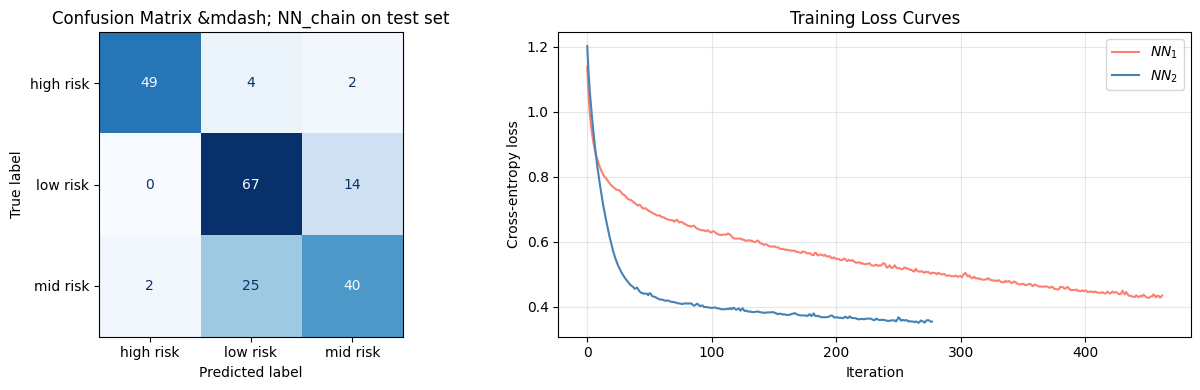

In [108]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_nn2,
    display_labels = le.classes_,
    cmap = 'Blues', ax = ax1, colorbar = False,
)
ax1.set_title("Confusion Matrix &mdash; NN_chain on test set")

ax2.plot(nn1.loss_curve_, color='salmon',    linewidth=1.5, label='$NN_1$')
ax2.plot(nn2.loss_curve_, color='steelblue', linewidth=1.5, label='$NN_2$')
ax2.set_title("Training Loss Curves")
ax2.set_xlabel("Iteration")
ax2.set_ylabel("Cross-entropy loss")
ax2.grid(alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

## $10.$ ***Expert System &mdash; Certainty Factors***

### *Combination formula:*
$$
total\_cf \;=\; total\_cf \;+\; cf \cdot (1 - total\_cf)
$$

> Each new piece of evidence has a **diminishing** effect &mdash; once $total\_cf$ is already high, the next CF can add only a little, and the combined CF can never exceed $1$.

### *Clinical rule base:*

| Rule | Condition | $cf$ |
|------|-----------|-----:|
| $R_1$ &mdash; High BP        | SystolicBP $\ge 140$ **or** DiastolicBP $\ge 90$ | $0.70$ |
| $R_2$ &mdash; High blood sugar| BS $\ge 11$ mmol/L | $0.65$ |
| $R_3$ &mdash; Fever           | BodyTemp $\ge 100$ °F | $0.40$ |
| $R_4$ &mdash; Tachycardia     | HeartRate $\ge 90$ bpm | $0.50$ |
| $R_5$ &mdash; Older mother    | Age $\ge 35$ years | $0.30$ |

### *Final-diagnosis thresholds:*

| Combined CF | Diagnosis |
|-------------|-----------|
| $\ge 0.70$           | **Likely HIGH risk**   |
| $0.40 \le cf < 0.70$ | **Possibly MID risk**  |
| $< 0.40$             | **Likely LOW risk**    |

In [109]:
cf_rules = {
    'high_bp'    : 0.70,
    'high_sugar' : 0.65,
    'fever'      : 0.40,
    'fast_heart' : 0.50,
    'older_mom'  : 0.30,
}


def check_rules(patient: dict) -> dict:
    return {
        'high_bp'    : bool(patient['SystolicBP'] >= 140 or patient['DiastolicBP'] >= 90),
        'high_sugar' : bool(patient['BS']         >= 11),
        'fever'      : bool(patient['BodyTemp']   >= 100),
        'fast_heart' : bool(patient['HeartRate']  >= 90),
        'older_mom'  : bool(patient['Age']        >= 35),
    }


def combine_cf(cf1: float, cf2: float) -> float:
    return cf1 + cf2 * (1 - cf1)

## $11.$ ***Hybrid Pipeline &mdash; `diagnose()`***

The end-to-end function:

&emsp;&emsp;&emsp; **(0)** *replay preprocessing* &mdash; log-skew transform on `skewed_columns`, then `StandardScaler`,<br>
&emsp;&emsp;&emsp; **(1)** $NN_1$ predicts class probabilities,<br>
&emsp;&emsp;&emsp; **(2)** $NN_2$ refines them given (scaled vitals $\Vert$ $NN_1$ probs),<br>
&emsp;&emsp;&emsp; **(3)** $P(\text{high risk})$ from $NN_2$ becomes the **seed CF**,<br>
&emsp;&emsp;&emsp; **(4)** clinical rules fire on the **raw** patient (not the scaled one) and add evidence,<br>
&emsp;&emsp;&emsp; **(5)** final $cf$ is thresholded into a verdict.<br>

> Note &mdash; we do **not** re-clamp the patient at inference: clamping is a training-data shaping step, and silently capping a real patient's vitals would be clinically wrong.

In [ ]:
HIGH_IDX      = list(le.classes_).index('high risk')
FEATURE_ORDER = list(X.columns)


def preprocess_patient(patient: dict, skewed_cols=None, scaler=scaler):
    if skewed_cols is None:
        skewed_cols = skewed_columns
    row = pd.DataFrame([patient])[FEATURE_ORDER].astype(float).copy()
    for col in skewed_cols:
        row[col] = np.sign(row[col]) * np.log1p(row[col].abs())
    return scaler.transform(row)


def diagnose(patient: dict, scaler=scaler, nn1=nn1, nn2=nn2, le=le, cf_rules=cf_rules):
    scaled = preprocess_patient(patient, skewed_columns, scaler)

    p1 = nn1.predict_proba(scaled)

    stage2 = np.hstack([scaled, p1])
    p2     = nn2.predict_proba(stage2)[0]
    nn_cf  = float(p2[HIGH_IDX])

    total_cf = nn_cf
    chain    = [('NN_chain P(high)', nn_cf)]
    for rule_name, present in check_rules(patient).items():
        if present:
            cf       = cf_rules[rule_name]
            total_cf = combine_cf(total_cf, cf)
            chain.append((f'rule: {rule_name}', cf))

    if   total_cf >= 0.70: verdict = 'Likely HIGH risk'
    elif total_cf >= 0.40: verdict = 'Possibly MID risk'
    else                 : verdict = 'Likely LOW risk'

    return {
        'verdict'    : verdict,
        'final_cf'   : round(total_cf, 4),
        'nn_cf'      : round(nn_cf,    4),
        'nn_probs'   : {cls: round(float(p), 4) for cls, p in zip(le.classes_, p2)},
        'chain'      : chain,
    }

In [111]:
def print_report(patient, result):
    print('=' * 64)
    print('  PATIENT INPUT')
    for k, v in patient.items():
        print(f'     {k:<13}: {v}')
    print('-' * 64)
    print('  NN_2 PROBABILITIES')
    for cls, p in result['nn_probs'].items():
        print(f'     P({cls:<10}) = {p:.4f}')
    print('-' * 64)
    print('  CHAIN OF EVIDENCE')
    running = 0.0
    for i, (name, cf) in enumerate(result['chain']):
        running = cf if i == 0 else combine_cf(running, cf)
        print(f'     + {name:<22} cf={cf:.3f}   running={running:.3f}')
    print('-' * 64)
    print(f"  FINAL CF  : {result['final_cf']:.4f}")
    print(f"  DIAGNOSIS : {result['verdict']}")
    print('=' * 64)

In [112]:
raw_data = pd.read_csv('data/Maternal Health Risk Data Set.csv')

for risk in ['high risk', 'mid risk', 'low risk']:
    sample  = raw_data[raw_data['RiskLevel'] == risk].sample(1, random_state=2026).iloc[0]
    patient = sample.drop('RiskLevel').to_dict()
    print(f"\n>>> ground-truth label: {risk}")
    print_report(patient, diagnose(patient))


>>> ground-truth label: high risk
  PATIENT INPUT
     Age          : 12
     SystolicBP   : 90
     DiastolicBP  : 60
     BS           : 7.9
     BodyTemp     : 102.0
     HeartRate    : 66
----------------------------------------------------------------
  NN_2 PROBABILITIES
     P(high risk ) = 0.8671
     P(low risk  ) = 0.0996
     P(mid risk  ) = 0.0333
----------------------------------------------------------------
  CHAIN OF EVIDENCE
     + NN_chain P(high)       cf=0.867   running=0.867
     + rule: fever            cf=0.400   running=0.920
----------------------------------------------------------------
  FINAL CF  : 0.9203
  DIAGNOSIS : Likely HIGH risk

>>> ground-truth label: mid risk
  PATIENT INPUT
     Age          : 17
     SystolicBP   : 90
     DiastolicBP  : 60
     BS           : 6.9
     BodyTemp     : 101.0
     HeartRate    : 76
----------------------------------------------------------------
  NN_2 PROBABILITIES
     P(high risk ) = 0.0030
     P(low risk  ) 

## $12.$ ***Saving the Model***

We save **five** artefacts so the interface can rebuild the pipeline from scratch:

&emsp;&emsp;**`models/nn1.joblib`**            &mdash; the Stage-1 MLP.<br>
&emsp;&emsp;**`models/nn2.joblib`**            &mdash; the Stage-2 refiner.<br>
&emsp;&emsp;**`models/scaler.joblib`**         &mdash; fitted `StandardScaler` (so we re-apply the **same** $\mu$ and $\sigma$).<br>
&emsp;&emsp;**`models/label_encoder.joblib`**  &mdash; mapping integers $\leftrightarrow$ `'low risk'/'mid risk'/'high risk'`.<br>
&emsp;&emsp;**`models/preprocess_meta.joblib`**&mdash; small dict carrying `feature_order`, `skewed_columns`, `clamp_bounds`, and the `cf_rules` table so the interface can replay everything exactly.

In [113]:
preprocess_meta = {
    'feature_order'  : FEATURE_ORDER,
    'skewed_columns' : skewed_columns,
    'clamp_bounds'   : clamp_bounds,
    'cf_rules'       : cf_rules,
    'high_idx'       : HIGH_IDX,
    'thresholds'     : {'high': 0.70, 'mid': 0.40},
}

joblib.dump(nn1,             'models/nn1.joblib')
joblib.dump(nn2,             'models/nn2.joblib')
joblib.dump(scaler,          'models/scaler.joblib')
joblib.dump(le,              'models/label_encoder.joblib')
joblib.dump(preprocess_meta, 'models/preprocess_meta.joblib')

print('saved files:')
print('  - models/nn1.joblib')
print('  - models/nn2.joblib')
print('  - models/scaler.joblib')
print('  - models/label_encoder.joblib')
print('  - models/preprocess_meta.joblib')

saved files:
  - models/nn1.joblib
  - models/nn2.joblib
  - models/scaler.joblib
  - models/label_encoder.joblib
  - models/preprocess_meta.joblib


In [114]:
nn1_loaded    = joblib.load('models/nn1.joblib')
nn2_loaded    = joblib.load('models/nn2.joblib')
scaler_loaded = joblib.load('models/scaler.joblib')
le_loaded     = joblib.load('models/label_encoder.joblib')
meta_loaded   = joblib.load('models/preprocess_meta.joblib')


def diagnose_from_disk(patient):
    row = pd.DataFrame([patient])[meta_loaded['feature_order']].astype(float).copy()
    for col in meta_loaded['skewed_columns']:
        row[col] = np.sign(row[col]) * np.log1p(row[col].abs())
    scaled = scaler_loaded.transform(row)

    p1     = nn1_loaded.predict_proba(scaled)
    stage2 = np.hstack([scaled, p1])
    p2     = nn2_loaded.predict_proba(stage2)[0]
    nn_cf  = float(p2[meta_loaded['high_idx']])

    total_cf = nn_cf
    for rule_name, present in check_rules(patient).items():
        if present:
            total_cf = combine_cf(total_cf, meta_loaded['cf_rules'][rule_name])

    th = meta_loaded['thresholds']
    if   total_cf >= th['high']: verdict = 'Likely HIGH risk'
    elif total_cf >= th['mid'] : verdict = 'Possibly MID risk'
    else                       : verdict = 'Likely LOW risk'
    return verdict, round(total_cf, 4)


for risk in ['high risk', 'mid risk', 'low risk']:
    sample  = raw_data[raw_data['RiskLevel'] == risk].sample(1, random_state=2026).iloc[0]
    patient = sample.drop('RiskLevel').to_dict()
    verdict_live = diagnose(patient)['verdict']
    verdict_disk, cf_disk = diagnose_from_disk(patient)
    ok = verdict_live == verdict_disk
    print(f"true: {risk:<10} | live: {verdict_live:<18} | from disk: {verdict_disk:<18} | cf={cf_disk}  {'OK' if ok else 'MISMATCH'}")

true: high risk  | live: Likely HIGH risk   | from disk: Likely HIGH risk   | cf=0.9203  OK
true: mid risk   | live: Possibly MID risk  | from disk: Possibly MID risk  | cf=0.4018  OK
true: low risk   | live: Likely LOW risk    | from disk: Likely LOW risk    | cf=0.0032  OK


## $13.$ ***Conclusion***

The two neural networks and the rule-based expert system **complete each other**:

&emsp;&emsp; $\bullet$ $NN_1$ learns patterns from $1\,014$ labelled patients and outputs an initial probability vector.<br>
&emsp;&emsp; $\bullet$ $NN_2$ refines that vector by looking at it together with the original scaled vitals.<br>
&emsp;&emsp; $\bullet$ $NN_2$'s $P(\text{high risk})$ becomes the **seed certainty factor** entering the expert system.<br>
&emsp;&emsp; $\bullet$ Five **clinical rules** check danger-zone vital signs and contribute additional CFs.<br>
&emsp;&emsp; $\bullet$ All CFs are combined with the course's formula and thresholded into a single human-readable verdict, with a full chain-of-evidence explanation.<br>

The trained system is persisted to **five joblib files** in `models/`. To wrap a UI around it, load all five, rebuild `diagnose_from_disk()`, and pass any patient dictionary in the format `{'Age': ..., 'SystolicBP': ..., 'DiastolicBP': ..., 'BS': ..., 'BodyTemp': ..., 'HeartRate': ...}`.